14:32:05 - cmdstanpy - INFO - Chain [1] start processing
14:32:05 - cmdstanpy - INFO - Chain [1] done processing
14:32:05 - cmdstanpy - INFO - Chain [1] start processing
14:32:05 - cmdstanpy - INFO - Chain [1] done processing
14:32:05 - cmdstanpy - INFO - Chain [1] start processing
14:32:06 - cmdstanpy - INFO - Chain [1] done processing
14:32:06 - cmdstanpy - INFO - Chain [1] start processing
14:32:06 - cmdstanpy - INFO - Chain [1] done processing
14:32:06 - cmdstanpy - INFO - Chain [1] start processing
14:32:06 - cmdstanpy - INFO - Chain [1] done processing
14:32:06 - cmdstanpy - INFO - Chain [1] start processing
14:32:06 - cmdstanpy - INFO - Chain [1] done processing
14:32:06 - cmdstanpy - INFO - Chain [1] start processing
14:32:06 - cmdstanpy - INFO - Chain [1] done processing
14:32:06 - cmdstanpy - INFO - Chain [1] start processing
14:32:06 - cmdstanpy - INFO - Chain [1] done processing
14:32:06 - cmdstanpy - INFO - Chain [1] start processing
14:32:06 - cmdstanpy - INFO - Chain [1]


=== PARAMS (Baselines) ===
Prophet best params: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 1.0}
SARIMA  best params: {'order': (2, 1, 2), 'seasonal_order': (0, 1, 1, 12)}

=== PERFORMANCE on TEST (2025-01..07) ===
                         MAE                                    RMSE  \
Approach      Hybrid-Prophet Hybrid-SARIMA XGB-direct Hybrid-Prophet   
Variant                                                                
full-basic             48.31         58.46      40.73          58.12   
full-extended          62.73         64.89      37.37          77.54   
orders-only            44.24         61.31      39.08          55.05   
stock-only             77.58         74.32      60.45          92.74   

                                                 MAPE                           
Approach      Hybrid-SARIMA XGB-direct Hybrid-Prophet Hybrid-SARIMA XGB-direct  
Variant                                                       

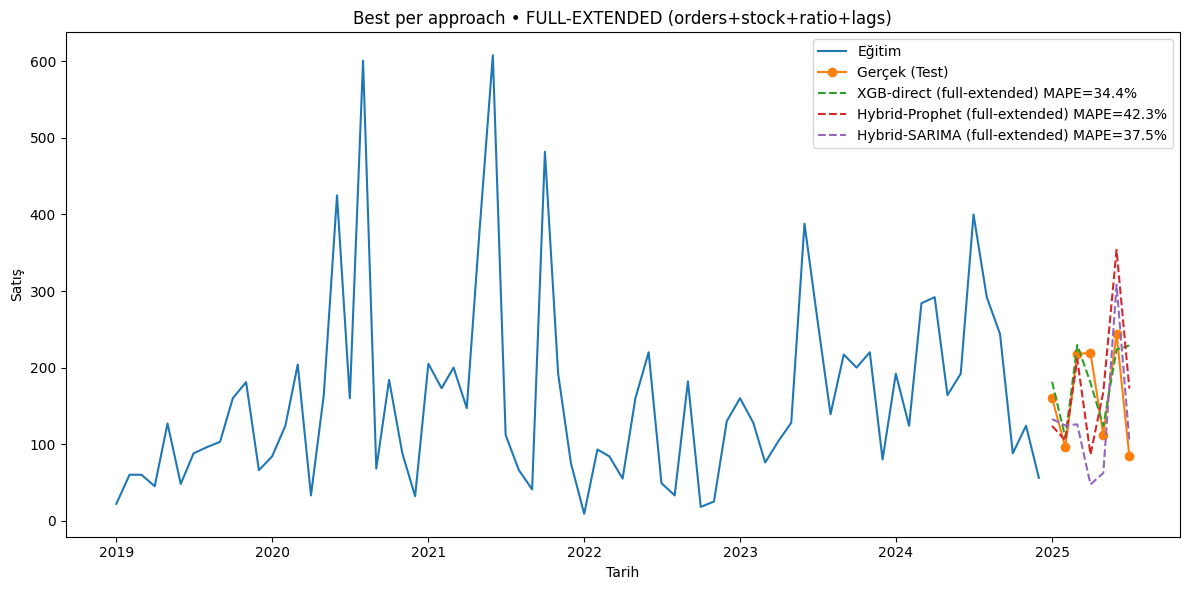

In [6]:
# ==============================================================
#  VARIANT BENCHMARK (FIXED): orders-only / stock-only / full-basic / full-extended
#  MODELS: XGBoost-direct, Hybrid-Prophet, Hybrid-SARIMA
#  SPLITS: TRAIN_FULL=2019-01..2024-12 | VAL=2024-07..2024-12 | TEST=2025-01..2025-07
#  All hyperparam searches on VAL, then refit on TRAIN_FULL, evaluate on TEST
# ==============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from io import StringIO

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ------------------ Config ------------------
TRAIN_END  = pd.Timestamp("2024-12-01")
VAL_START  = pd.Timestamp("2024-07-01")
VAL_END    = pd.Timestamp("2024-12-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-07-01")

RANDOM_STATE = 42

# ------------------ Data: Sales ------------------
sales_data = {
"2019-01":22,"2019-02":60,"2019-03":60,"2019-04":45,"2019-05":127,
"2019-06":48,"2019-07":88,"2019-08":96,"2019-09":103,"2019-10":160,
"2019-11":181,"2019-12":66,"2020-01":84,"2020-02":124,"2020-03":204,
"2020-04":33,"2020-05":164,"2020-06":425,"2020-07":160,"2020-08":601,
"2020-09":68,"2020-10":184,"2020-11":88,"2020-12":32,"2021-01":205,
"2021-02":173,"2021-03":200,"2021-04":147,"2021-05":380,"2021-06":608,
"2021-07":112,"2021-08":66,"2021-09":41,"2021-10":482,"2021-11":192,
"2021-12":75,"2022-01":9,"2022-02":93,"2022-03":84,"2022-04":55,
"2022-05":160,"2022-06":220,"2022-07":49,"2022-08":33,"2022-09":182,
"2022-10":18,"2022-11":25,"2022-12":130,"2023-01":160,"2023-02":128,
"2023-03":76,"2023-04":104,"2023-05":128,"2023-06":388,"2023-07":264,
"2023-08":139,"2023-09":217,"2023-10":200,"2023-11":220,"2023-12":80,
"2024-01":192,"2024-02":124,"2024-03":284,"2024-04":292,"2024-05":164,
"2024-06":192,"2024-07":400,"2024-08":292,"2024-09":244,"2024-10":88,
"2024-11":124,"2024-12":56,"2025-01":160,"2025-02":96,"2025-03":218,
"2025-04":219,"2025-05":112,"2025-06":244,"2025-07":84
}
sales = pd.Series(sales_data)
sales.index = pd.to_datetime(sales.index)  # Month Start

# ------------------ Data: Orders ------------------
orders_raw = """SalesYear SalesMonth TotalQty
2019 1 16
2019 2 64
2019 3 72
2019 4 37
2019 5 135
2019 6 48
2019 7 96
2019 8 132
2019 9 137
2019 10 136
2019 11 173
2019 12 67
2020 1 64
2020 2 624
2020 3 197
2020 4 33
2020 5 164
2020 6 617
2020 7 132
2020 8 636
2020 9 56
2020 10 224
2020 11 48
2020 12 32
2021 1 249
2021 2 233
2021 3 368
2021 4 447
2021 5 596
2021 6 360
2021 7 144
2021 8 61
2021 9 378
2021 10 454
2021 11 228
2021 12 79
2022 1 6
2022 2 117
2022 3 92
2022 4 70
2022 5 240
2022 6 292
2022 7 57
2022 8 36
2022 9 222
2022 10 20
2022 11 40
2022 12 134
2023 1 229
2023 2 112
2023 3 80
2023 4 113
2023 5 160
2023 6 480
2023 7 252
2023 8 219
2023 9 173
2023 10 408
2023 11 196
2023 12 136
2024 1 284
2024 2 404
2024 3 324
2024 4 288
2024 5 158
2024 6 216
2024 7 760
2024 8 396
2024 9 249
2024 10 84
2024 11 128
2024 12 56
2025 1 176
2025 2 96
2025 3 256
2025 4 216
2025 5 136
2025 6 244
2025 7 192
2025 8 197
"""
orders = pd.read_csv(StringIO(orders_raw), sep=r"\s+")
orders["ds"] = pd.to_datetime(orders["SalesYear"].astype(str)+"-"+orders["SalesMonth"].astype(str)+"-01")
orders = orders[["ds","TotalQty"]].rename(columns={"TotalQty":"orders"})

# ------------------ Data: Stocks ------------------
stocks_csv = """ItemCode,MonthStart,AyBasi_Stok
303-104092,2019-01-01,0
303-104092,2019-02-01,-22
303-104092,2019-03-01,-2
303-104092,2019-04-01,38
303-104092,2019-05-01,-7
303-104092,2019-06-01,-14
303-104092,2019-07-01,-28
303-104092,2019-08-01,4
303-104092,2019-09-01,68
303-104092,2019-10-01,1
303-104092,2019-11-01,105
303-104092,2019-12-01,84
303-104092,2020-01-01,18
303-104092,2020-02-01,54
303-104092,2020-03-01,70
303-104092,2020-04-01,349
303-104092,2020-05-01,356
303-104092,2020-06-01,192
303-104092,2020-07-01,166
303-104092,2020-08-01,262
303-104092,2020-09-01,181
303-104092,2020-10-01,165
303-104092,2020-11-01,1
303-104092,2020-12-01,133
303-104092,2021-01-01,117
303-104092,2021-02-01,32
303-104092,2021-03-01,31
303-104092,2021-04-01,111
303-104092,2021-05-01,128
303-104092,2021-06-01,-12
303-104092,2021-07-01,244
303-104092,2021-08-01,172
303-104092,2021-09-01,138
303-104092,2021-10-01,577
303-104092,2021-11-01,95
303-104092,2021-12-01,23
303-104092,2022-01-01,104
303-104092,2022-02-01,94
303-104092,2022-03-01,149
303-104092,2022-04-01,157
303-104092,2022-05-01,102
303-104092,2022-06-01,262
303-104092,2022-07-01,281
303-104092,2022-08-01,232
303-104092,2022-09-01,199
303-104092,2022-10-01,181
303-104092,2022-11-01,223
303-104092,2022-12-01,198
303-104092,2023-01-01,68
303-104092,2023-02-01,76
303-104092,2023-03-01,48
303-104092,2023-04-01,92
303-104092,2023-05-01,28
303-104092,2023-06-01,100
303-104092,2023-07-01,212
303-104092,2023-08-01,188
303-104092,2023-09-01,49
303-104092,2023-10-01,132
303-104092,2023-11-01,92
303-104092,2023-12-01,32
303-104092,2024-01-01,-8
303-104092,2024-02-01,104
303-104092,2024-03-01,-12
303-104092,2024-04-01,144
303-104092,2024-05-01,72
303-104092,2024-06-01,216
303-104092,2024-07-01,24
303-104092,2024-08-01,4
303-104092,2024-09-01,248
303-104092,2024-10-01,216
303-104092,2024-11-01,127
303-104092,2024-12-01,167
303-104092,2025-01-01,153
303-104092,2025-02-01,145
303-104092,2025-03-01,97
303-104092,2025-04-01,78
303-104092,2025-05-01,139
303-104092,2025-06-01,187
303-104092,2025-07-01,35
303-104092,2025-08-01,-29
303-104092,2025-09-01,130
"""
stocks = pd.read_csv(StringIO(stocks_csv))
stocks["ds"] = pd.to_datetime(stocks["MonthStart"])
stocks = stocks[["ds","AyBasi_Stok"]].rename(columns={"AyBasi_Stok":"stock"})

# ------------------ Merge Master DF ------------------
df = (pd.DataFrame({"ds": sales.index, "y": sales.values})
      .merge(orders, on="ds", how="left")
      .merge(stocks, on="ds", how="left"))

# ------------------ Feature helpers ------------------
def add_calendar_and_lags(z: pd.DataFrame) -> pd.DataFrame:
    z = z.copy()
    z["month"] = z["ds"].dt.month
    z["year"] = z["ds"].dt.year
    z["is_summer"] = z["ds"].dt.month.isin([6,7,8]).astype(int)
    z["is_winter"] = z["ds"].dt.month.isin([12,1,2]).astype(int)
    # lags of y (for residual models)
    z["lag1"]  = z["y"].shift(1)
    z["lag12"] = z["y"].shift(12)
    # exog lags (for full-extended)
    z["orders_lag1"]  = z["orders"].shift(1)
    z["orders_lag12"] = z["orders"].shift(12)
    z["stock_lag1"]   = z["stock"].shift(1)
    z["stock_lag12"]  = z["stock"].shift(12)
    # ratio
    z["orders_ratio"] = z["orders"] / z["stock"].replace(0, np.nan)
    z.replace([np.inf, -np.inf], np.nan, inplace=True)
    return z

def select_feature_cols(variant: str, for_residual: bool, with_ratio_lags: bool):
    base = ["month","year","is_summer","is_winter"]
    cols = base.copy()
    if variant == "orders":
        cols += ["orders"]
    elif variant == "stock":
        cols += ["stock"]
    elif variant == "full":
        cols += ["orders","stock"]
        if with_ratio_lags:
            cols += ["orders_ratio","orders_lag1","orders_lag12","stock_lag1","stock_lag12"]
    if for_residual:
        cols += ["lag1","lag12"]
    return cols

def mae_rmse_mape(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1, y_true))) * 100
    return mae, rmse, mape

# ------------------ Prophet Optimization ------------------
def optimize_prophet(df_train_in, df_val):
    grid = {
        "changepoint_prior_scale": [0.01, 0.05, 0.1],
        "seasonality_mode": ["additive", "multiplicative"],
        "seasonality_prior_scale": [1.0, 5.0]
    }
    best, best_mae = None, np.inf
    for cps, smode, sps in product(grid["changepoint_prior_scale"], grid["seasonality_mode"], grid["seasonality_prior_scale"]):
        try:
            m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                        changepoint_prior_scale=cps, seasonality_mode=smode,
                        seasonality_prior_scale=sps)
            m.fit(df_train_in[["ds","y"]])
            future = m.make_future_dataframe(periods=len(df_val), freq="MS")
            fcst = m.predict(future)[["ds","yhat"]]
            y_pred = fcst[fcst["ds"].isin(df_val["ds"])]["yhat"].to_numpy()
            y_true = df_val["y"].to_numpy()
            mae, _, _ = mae_rmse_mape(y_true, y_pred)
            if mae < best_mae:
                best_mae = mae
                best = {"changepoint_prior_scale":cps, "seasonality_mode":smode, "seasonality_prior_scale":sps}
        except Exception:
            continue
    m_full = Prophet(yearly_seasonality=True, weekly_seasonality=False, **best)
    return best, m_full

def prophet_fit_predict(m_full, df_train_full, periods_needed):
    m_full.fit(df_train_full[["ds","y"]])
    future = m_full.make_future_dataframe(periods=periods_needed, freq="MS")
    fcst = m_full.predict(future)[["ds","yhat"]]
    return fcst

# ------------------ SARIMA Optimization ------------------
def optimize_sarima(series_train_in, series_val):
    pdq_list  = [(p,1,q) for p in [0,1,2] for q in [0,1,2]]
    PDQ_list  = [(P,1,Q,12) for P in [0,1] for Q in [0,1]]
    best, best_mae = None, np.inf
    len_val = len(series_val)
    for order in pdq_list:
        for sorder in PDQ_list:
            try:
                model = SARIMAX(series_train_in, order=order, seasonal_order=sorder,
                                enforce_stationarity=False, enforce_invertibility=False)
                res = model.fit(disp=False)
                fc = res.get_forecast(steps=len_val).predicted_mean.to_numpy()
                mae, _, _ = mae_rmse_mape(series_val.to_numpy(), fc)
                if mae < best_mae:
                    best_mae = mae
                    best = {"order":order, "seasonal_order":sorder}
            except Exception:
                continue
    return best

def sarima_fit_predict(params, series_train_full, steps_needed):
    model = SARIMAX(series_train_full, order=params["order"], seasonal_order=params["seasonal_order"],
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    fitted = res.fittedvalues
    fc = res.get_forecast(steps=steps_needed).predicted_mean
    return fitted, fc

# ------------------ XGBoost Optimization ------------------
def optimize_xgb(X_train_in, y_train_in, X_val, y_val):
    grid = {
        "n_estimators": [300, 500],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3, 4],
        "subsample": [0.9],
        "colsample_bytree": [0.9],
        "reg_lambda": [1.0, 2.0]
    }
    best_params, best_mae = None, np.inf
    for n, lr, md, ss, cs, rl in product(grid["n_estimators"], grid["learning_rate"], grid["max_depth"],
                                         grid["subsample"], grid["colsample_bytree"], grid["reg_lambda"]):
        params = dict(n_estimators=n, learning_rate=lr, max_depth=md,
                      subsample=ss, colsample_bytree=cs, reg_lambda=rl,
                      random_state=RANDOM_STATE)
        model = XGBRegressor(**params)
        model.fit(X_train_in, y_train_in)
        val_pred = model.predict(X_val)
        mae, _, _ = mae_rmse_mape(y_val, val_pred)
        if mae < best_mae:
            best_mae, best_params = mae, params
    return best_params

# ------------------ Build feature DF and splits ------------------
feat = add_calendar_and_lags(df)
feat.replace([np.inf, -np.inf], np.nan, inplace=True)

mask_train_full = feat["ds"] <= TRAIN_END
mask_val        = (feat["ds"] >= VAL_START) & (feat["ds"] <= VAL_END)
mask_train_in   = (feat["ds"] < VAL_START)
mask_test       = (feat["ds"] >= TEST_START) & (feat["ds"] <= TEST_END)

train_in_df   = feat.loc[mask_train_in].copy()
val_df        = feat.loc[mask_val].copy()
train_full_df = feat.loc[mask_train_full].copy()
test_df       = feat.loc[mask_test].copy()

# ------------------ Optimize & Fit Baselines ------------------
# Prophet
prophet_params, prophet_model_full = optimize_prophet(train_in_df[["ds","y"]], val_df[["ds","y"]])
fcst_prophet = prophet_fit_predict(prophet_model_full, train_full_df[["ds","y"]], periods_needed=len(test_df))
# Merge Prophet yhat into feat (safe)
feat = feat.merge(fcst_prophet, on="ds", how="left")

# SARIMA
series_train_in    = train_in_df.set_index("ds")["y"]
series_val         = val_df.set_index("ds")["y"]
series_train_full  = train_full_df.set_index("ds")["y"]
sarima_params = optimize_sarima(series_train_in, series_val)
fitted_sarima, fc_sarima = sarima_fit_predict(sarima_params, series_train_full, steps_needed=len(test_df))

# Attach SARIMA in-sample yhat to feat via merge (FIX)
feat["yhat_sarima"] = np.nan
fitted_df = pd.DataFrame({"ds": series_train_full.index, "yhat_sarima": fitted_sarima.values})
feat = feat.merge(fitted_df, on="ds", how="left", suffixes=("", "_tmp"))
feat["yhat_sarima"] = feat["yhat_sarima"].fillna(feat["yhat_sarima_tmp"])
feat.drop(columns=["yhat_sarima_tmp"], inplace=True)

# ------------------ Variants ------------------
variants = [
    ("orders-only",   "orders", False),
    ("stock-only",    "stock",  False),
    ("full-basic",    "full",   False),
    ("full-extended", "full",   True),
]

results = []

def run_xgb_direct(variant_name, kind, with_ratio_lags):
    cols_in   = select_feature_cols(kind, for_residual=False, with_ratio_lags=with_ratio_lags)
    X_train_in= train_in_df[cols_in].copy().fillna(0)
    y_train_in= train_in_df["y"].copy()
    X_val     = val_df[cols_in].copy().fillna(0)
    y_val     = val_df["y"].copy()

    best_params = optimize_xgb(X_train_in, y_train_in, X_val, y_val)

    # Refit on TRAIN_FULL and predict TEST
    X_train_full= train_full_df[cols_in].copy().fillna(0)
    y_train_full= train_full_df["y"].copy()
    model = XGBRegressor(**best_params)
    model.fit(X_train_full, y_train_full)
    X_test = test_df[cols_in].copy().fillna(0)
    y_pred = model.predict(X_test)

    mae, rmse, mape = mae_rmse_mape(test_df["y"].to_numpy(), y_pred)
    results.append({"Approach":"XGB-direct","Variant":variant_name,"Params":best_params,
                    "MAE":mae,"RMSE":rmse,"MAPE":mape,"Pred":y_pred})

def run_hybrid_prophet(variant_name, kind, with_ratio_lags):
    cols_in = select_feature_cols(kind, for_residual=True, with_ratio_lags=with_ratio_lags)

    # Build temporary Prophet on TRAIN_IN to produce residuals for TRAIN_IN & VAL
    m_tmp = Prophet(yearly_seasonality=True, weekly_seasonality=False, **prophet_params)
    m_tmp.fit(train_in_df[["ds","y"]])
    tmp_future = m_tmp.make_future_dataframe(periods=len(val_df), freq="MS")
    tmp_fcst = m_tmp.predict(tmp_future)[["ds","yhat"]].rename(columns={"yhat":"yhat_tmp"})

    tmp = feat.merge(tmp_fcst, on="ds", how="left")

    tr_in = tmp.loc[mask_train_in].copy()
    tr_in["residual_tmp"] = tr_in["y"] - tr_in["yhat_tmp"]
    vl = tmp.loc[mask_val].copy()
    vl["residual_tmp"] = vl["y"] - vl["yhat_tmp"]

    X_train_in = tr_in[cols_in].copy().fillna(0)
    y_train_in = tr_in["residual_tmp"].copy()
    X_val      = vl[cols_in].copy().fillna(0)
    y_val      = vl["residual_tmp"].copy()

    best_params = optimize_xgb(X_train_in, y_train_in, X_val, y_val)

    # Final residual model using full Prophet yhat already in feat['yhat']
    tmp_full = feat.loc[mask_train_full].copy()
    tmp_full["residual"] = tmp_full["y"] - tmp_full["yhat"]
    X_train_full = tmp_full[cols_in].copy().fillna(0)
    y_train_full = tmp_full["residual"].copy()

    model = XGBRegressor(**best_params)
    model.fit(X_train_full, y_train_full)

    X_test = feat.loc[mask_test, cols_in].copy().fillna(0)
    resid_pred = model.predict(X_test)
    base_pred  = feat.loc[mask_test, "yhat"].to_numpy()
    y_pred = base_pred + resid_pred

    mae, rmse, mape = mae_rmse_mape(test_df["y"].to_numpy(), y_pred)
    results.append({"Approach":"Hybrid-Prophet","Variant":variant_name,
                    "Params":{"prophet":prophet_params,"xgb":best_params},
                    "MAE":mae,"RMSE":rmse,"MAPE":mape,"Pred":y_pred})

def run_hybrid_sarima(variant_name, kind, with_ratio_lags):
    cols_in = select_feature_cols(kind, for_residual=True, with_ratio_lags=with_ratio_lags)

    # TRAIN_IN fit SARIMA and produce fitted for TRAIN_IN + forecast for VAL
    model_in = SARIMAX(series_train_in, order=sarima_params["order"], seasonal_order=sarima_params["seasonal_order"],
                       enforce_stationarity=False, enforce_invertibility=False)
    res_in = model_in.fit(disp=False)
    fitted_in = res_in.fittedvalues
    fc_val = res_in.get_forecast(steps=len(val_df)).predicted_mean

    # Merge fitted/forecast safely into a temp df
    tmp = feat.copy()
    df_in_fit = pd.DataFrame({"ds": series_train_in.index, "yhat_sarima_inval": fitted_in.values})
    tmp = tmp.merge(df_in_fit, on="ds", how="left")
    tmp.loc[tmp["ds"].isin(val_df["ds"]), "yhat_sarima_inval"] = fc_val.to_numpy()

    tr_in = tmp.loc[mask_train_in].copy()
    tr_in["residual_tmp"] = tr_in["y"] - tr_in["yhat_sarima_inval"]
    vl = tmp.loc[mask_val].copy()
    vl["residual_tmp"] = vl["y"] - vl["yhat_sarima_inval"]

    X_train_in = tr_in[cols_in].copy().fillna(0)
    y_train_in = tr_in["residual_tmp"].copy()
    X_val      = vl[cols_in].copy().fillna(0)
    y_val      = vl["residual_tmp"].copy()

    best_params = optimize_xgb(X_train_in, y_train_in, X_val, y_val)

    # Final residual model with full SARIMA yhat already merged in feat['yhat_sarima']
    tmp_full = feat.loc[mask_train_full].copy()
    tmp_full["residual"] = tmp_full["y"] - tmp_full["yhat_sarima"]
    X_train_full = tmp_full[cols_in].copy().fillna(0)
    y_train_full = tmp_full["residual"].copy()

    model = XGBRegressor(**best_params)
    model.fit(X_train_full, y_train_full)

    base_pred = fc_sarima.to_numpy()  # TEST forecast from full SARIMA fit
    X_test = feat.loc[mask_test, cols_in].copy().fillna(0)
    resid_pred = model.predict(X_test)
    y_pred = base_pred + resid_pred

    mae, rmse, mape = mae_rmse_mape(test_df["y"].to_numpy(), y_pred)
    results.append({"Approach":"Hybrid-SARIMA","Variant":variant_name,
                    "Params":{"sarima":sarima_params,"xgb":best_params},
                    "MAE":mae,"RMSE":rmse,"MAPE":mape,"Pred":y_pred})

# ------------------ Run all experiments ------------------
for vname, kind, with_rl in variants:
    run_xgb_direct(vname, kind, with_rl)
    run_hybrid_prophet(vname, kind, with_rl)
    run_hybrid_sarima(vname, kind, with_rl)

# ------------------ Report ------------------
res_df = pd.DataFrame([{
    "Approach": r["Approach"],
    "Variant": r["Variant"],
    "MAE": r["MAE"],
    "RMSE": r["RMSE"],
    "MAPE": r["MAPE"]
} for r in results]).sort_values(by=["Variant","Approach"]).reset_index(drop=True)

print("\n=== PARAMS (Baselines) ===")
print("Prophet best params:", prophet_params)
print("SARIMA  best params:", sarima_params)

print("\n=== PERFORMANCE on TEST (2025-01..07) ===")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(res_df.pivot(index="Variant", columns="Approach", values=["MAE","RMSE","MAPE"]))

# ------------------ Plot best-of-each-approach on full-extended ------------------
subset = [r for r in results if r["Variant"]=="full-extended"]
if subset:
    best_direct = min([r for r in subset if r["Approach"]=="XGB-direct"], key=lambda z: z["MAPE"])
    best_hprop  = min([r for r in subset if r["Approach"]=="Hybrid-Prophet"], key=lambda z: z["MAPE"])
    best_hsari  = min([r for r in subset if r["Approach"]=="Hybrid-SARIMA"], key=lambda z: z["MAPE"])

    dates_test = test_df["ds"].to_numpy()
    y_true = test_df["y"].to_numpy()

    plt.figure(figsize=(12,6))
    plt.plot(train_full_df["ds"], train_full_df["y"], label="Eğitim")
    plt.plot(dates_test, y_true, "o-", label="Gerçek (Test)")

    plt.plot(dates_test, best_direct["Pred"], "--", label=f"XGB-direct (full-extended) MAPE={best_direct['MAPE']:.1f}%")
    plt.plot(dates_test, best_hprop["Pred"],  "--", label=f"Hybrid-Prophet (full-extended) MAPE={best_hprop['MAPE']:.1f}%")
    plt.plot(dates_test, best_hsari["Pred"],  "--", label=f"Hybrid-SARIMA (full-extended) MAPE={best_hsari['MAPE']:.1f}%")

    plt.title("Best per approach • FULL-EXTENDED (orders+stock+ratio+lags)")
    plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
    plt.show()
